In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern

from utils import *

# Parser
COACH_DIR = Path("/Users/hyeon/SeSAC_Project/Coach")    # Coach의 절대경로 입력
RUN_FOLDER = "test11"
RUN_DIR = COACH_DIR / "run" / RUN_FOLDER

# 루트 디렉토리 바로 아래의 pose_predictions.json 지정
OUTPUTS_DIR = RUN_DIR / "outputs"

user = RUN_DIR / "user_info.json"
with user.open(mode="r", encoding='utf-8') as file:
    user_data = json.load(file)

hpe = OUTPUTS_DIR / "pose_predictions.json"
with hpe.open(mode="r", encoding='utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode="r", encoding='utf-8') as file:
    detail_data = json.load(file)

ps = PoseSequence(pose_data, detail_data, user_data)


In [2]:
knee = ps.joint_angle('left_knee', smooth=True, negative=True)

In [3]:
distance = ps.details["video"]['fps'] // 6

In [4]:
distance

10.0

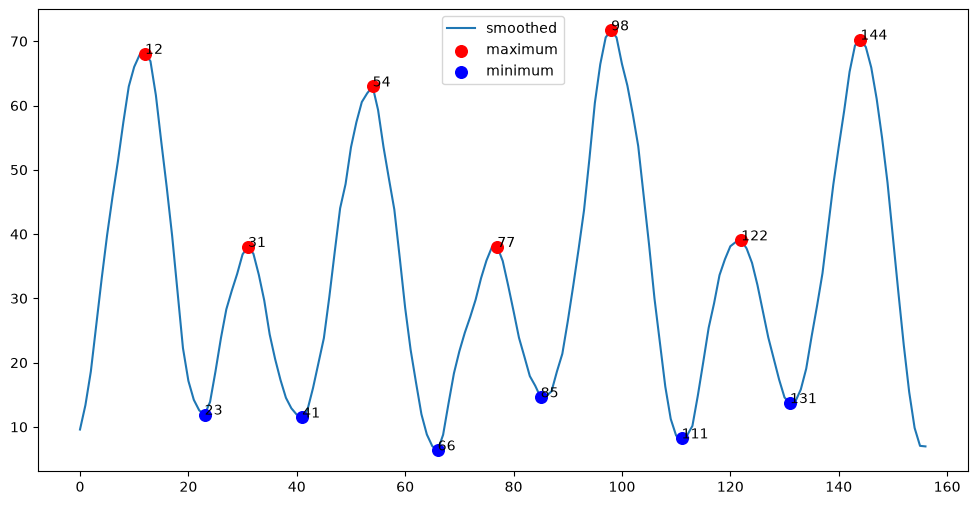

최댓값 프레임: [ 12  31  54  77  98 122 144]
최솟값 프레임: [ 23  41  66  85 111 131]


In [5]:
# 데이터 범위에 비례해 prominence 설정
signal_range = np.percentile(knee, 95) - np.percentile(knee, 5)
prominence = signal_range * 0.1    # 곱해지는 숫자가 클수록 큰 봉우리만 검출

# 최댓값
max_indices, max_properties = find_peaks(
    knee,
    prominence=prominence,
    distance=distance,
)

# 최솟값: 신호에 -를 붙여서 봉우리로 변환
min_indices, min_properties = find_peaks(
    -knee,
    prominence=prominence,
    distance=distance,
)

plt.figure(figsize=(12, 6))
plt.plot(knee, label="smoothed")

plt.scatter(
    max_indices,
    knee[max_indices],
    color="red",
    s=70,
    label="maximum",
    zorder=3,
)

plt.scatter(
    min_indices,
    knee[min_indices],
    color="blue",
    s=70,
    label="minimum",
    zorder=3,
)

for i in max_indices:
    plt.annotate(str(i), (i, knee[i]))

for i in min_indices:
    plt.annotate(str(i), (i, knee[i]))

plt.legend()
plt.show()

print("최댓값 프레임:", max_indices)
print("최솟값 프레임:", min_indices)

In [6]:
start_index = (0 if knee[max_indices[0]] > knee[max_indices[1]] else 1)
for i in range(len(max_indices) // 2):
    assert knee[max_indices[2 * i + start_index]] > knee[max_indices[2 * i + 1 + start_index]]

In [7]:
start_frame = max_indices[start_index]

In [8]:
ps.cal_stride()

,frame,value,class
1,12,68.043441,1
2,23,11.905859,0
3,31,38.002349,1
4,41,11.463123,0
1,54,62.956999,1
2,66,6.346456,0
3,77,37.995394,1
4,85,14.598677,0
1,98,71.685014,1
2,111,8.213956,0


In [9]:
ps.gct(
)

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0032082241987640447 / pixel 입니다.


[[28, 47], [69, 89], [115, 132]]

In [10]:
for i, j in [[1, 2], [3, 4]]:
    print(i, j)

1 2
3 4


In [34]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0032082241987640447 / pixel 입니다.


np.float64(551.7070785395501)

In [35]:
0.01 / ps.m_per_pixel

np.float64(3.1169891442912436)

In [11]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


def show_video_frames(
    video_path,
    frames,
    hpe_start_frame=0,
    *,
    columns=2,
):
    """
    HPE 기준 프레임을 원본 영상 프레임으로 변환해 출력한다.

    Args:
        video_path:
            원본 영상 경로
        frames:
            HPE 기준 프레임 번호.
            정수, 리스트, 또는 ps.gct()의 [[td, to], ...] 형식
        hpe_start_frame:
            원본 영상에서 HPE 분석이 시작된 프레임 번호
        columns:
            이미지 출력 열 개수

    Returns:
        list[np.ndarray]:
            RGB 형식의 프레임 이미지
    """
    video_path = Path(video_path)

    if not video_path.is_file():
        raise FileNotFoundError(
            f"영상 파일이 없습니다: {video_path}"
        )

    try:
        hpe_frames = np.asarray(
            frames,
            dtype=float,
        ).reshape(-1)
    except (TypeError, ValueError) as exc:
        raise TypeError(
            "frames는 정수 또는 정수 배열이어야 합니다."
        ) from exc

    if hpe_frames.size == 0:
        raise ValueError("확인할 프레임이 없습니다.")

    if (
        not np.all(np.isfinite(hpe_frames))
        or not np.all(hpe_frames == np.floor(hpe_frames))
    ):
        raise ValueError("프레임 번호는 유한한 정수여야 합니다.")

    hpe_frames = hpe_frames.astype(int)

    # HPE 기준 프레임 → 원본 영상 프레임
    video_frames = hpe_frames + int(hpe_start_frame)

    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        raise RuntimeError(
            f"영상을 열지 못했습니다: {video_path}"
        )

    images = []

    try:
        frame_count = int(
            capture.get(cv2.CAP_PROP_FRAME_COUNT)
        )
        fps = float(
            capture.get(cv2.CAP_PROP_FPS)
        )

        invalid = video_frames[
            (video_frames < 0)
            | (video_frames >= frame_count)
        ]

        if invalid.size:
            raise IndexError(
                f"영상 프레임 범위를 벗어났습니다: "
                f"{invalid.tolist()} "
                f"(유효 범위: 0~{frame_count - 1})"
            )

        for video_frame in video_frames:
            capture.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(video_frame),
            )

            success, bgr_image = capture.read()

            if not success:
                raise RuntimeError(
                    f"{video_frame}번 프레임을 읽지 못했습니다."
                )

            rgb_image = cv2.cvtColor(
                bgr_image,
                cv2.COLOR_BGR2RGB,
            )
            images.append(rgb_image)

    finally:
        capture.release()

    columns = max(
        1,
        min(int(columns), len(images)),
    )
    rows = int(np.ceil(len(images) / columns))

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(5 * columns, 4 * rows),
    )
    axes = np.atleast_1d(axes).reshape(-1)

    for axis, image, hpe_frame, video_frame in zip(
        axes,
        images,
        hpe_frames,
        video_frames,
    ):
        seconds = (
            video_frame / fps
            if fps > 0
            else float("nan")
        )

        axis.imshow(image)
        axis.set_title(
            f"HPE {hpe_frame} → "
            f"video {video_frame} "
            f"({seconds:.3f}s)"
        )
        axis.axis("off")

    for axis in axes[len(images):]:
        axis.axis("off")

    figure.tight_layout()
    plt.show()

    return images

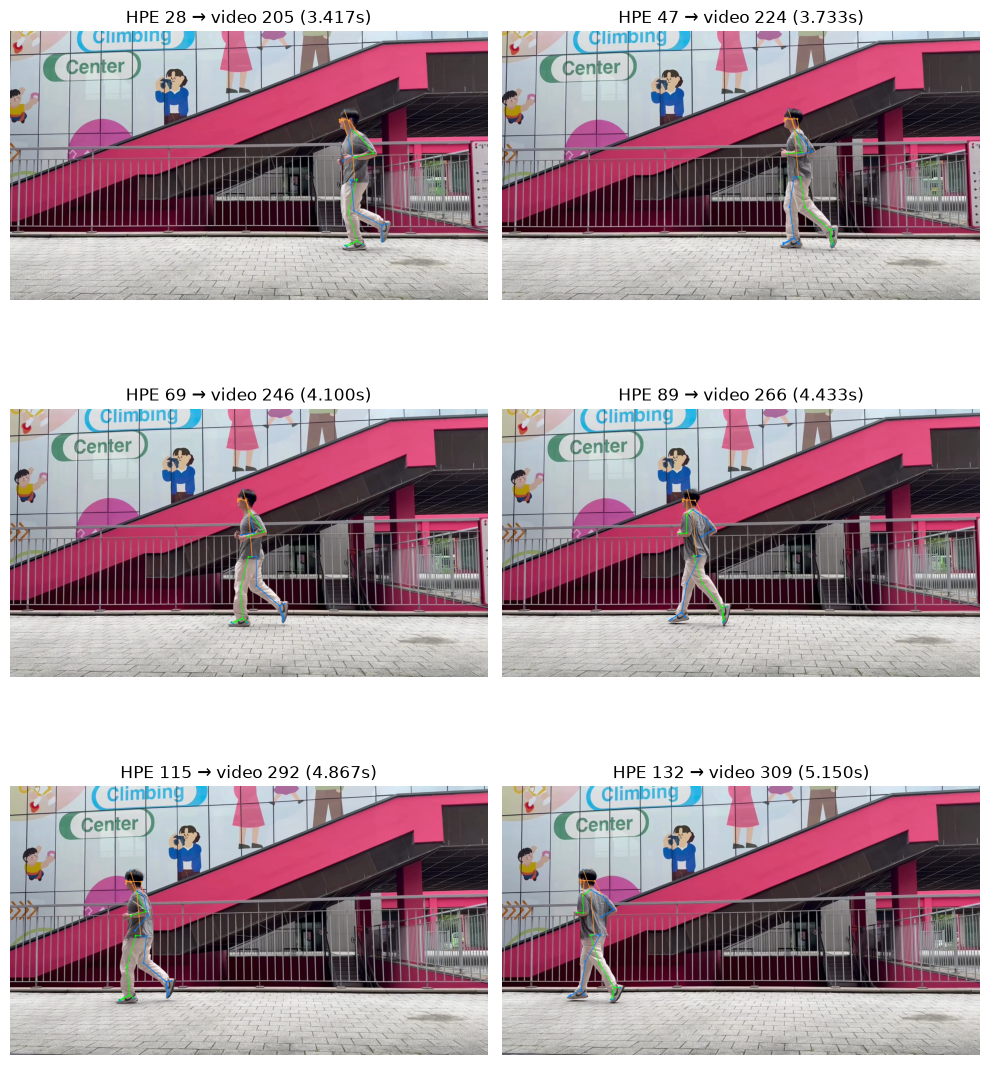

In [12]:
# pose_data에 기록된 실제 HPE 시작 프레임
hpe_start_frame = pose_data["frames"][0]["frame_num"]

# details.json의 relative_path는 Coach 폴더 기준
video_path = (
    Path("/Users/hyeon/SeSAC_Project/Coach")
    / 'run' / 'test11' / 'outputs' / 'output.mp4'
)

gct_frames = ps.gct()

images = show_video_frames(
    video_path,
    gct_frames,
    hpe_start_frame=hpe_start_frame,
)

In [13]:
ps.gct()

[[28, 47], [69, 89], [115, 132]]

In [14]:
np.resize([1, 2, 3, 4], sum(ps.strides.frame >= start_frame) + 4)[np.where(ps.strides.frame == start_frame)[0][0]:]

array([1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1])

In [15]:
max_indices

array([ 12,  31,  54,  77,  98, 122, 144])

In [16]:
ps.cal_stride() 

이미 stride가 계산되어 있습니다.
Stride :    frame      value  class
1     12  68.043441      1
2     23  11.905859      0
3     31  38.002349      1
4     41  11.463123      0
1     54  62.956999      1
2     66   6.346456      0
3     77  37.995394      1
4     85  14.598677      0
1     98  71.685014      1
2    111   8.213956      0
3    122  39.025264      1
4    131  13.702387      0
1    144  70.255043      1


In [17]:
len(ps.strides)

13

In [18]:
ps.strides

,frame,value,class
1,12,68.043441,1
2,23,11.905859,0
3,31,38.002349,1
4,41,11.463123,0
1,54,62.956999,1
2,66,6.346456,0
3,77,37.995394,1
4,85,14.598677,0
1,98,71.685014,1
2,111,8.213956,0


In [19]:
len(ps.gct())

3

In [20]:
a = 1

In [21]:
np.asarray(a).reshape(-1)[0]

np.int64(1)

In [22]:
ps.df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1574.294067,782.769226,1899.782959,201.620300,1595.156504,726.773106,1603.669429,739.069551,1592.318863,737.177790,...,1601.777668,232.077650,1853.381872,223.564726,1604.615309,237.752932,1870.407720,271.804627,1669.881061,240.590573
1,1569.331177,779.577271,1881.955200,200.543884,1585.220050,726.612277,1592.759547,737.921523,1582.392738,736.979086,...,1589.932236,231.832762,1853.814644,224.293264,1591.817110,236.544948,1863.239016,277.069746,1659.672586,239.372259
2,1561.562988,779.943970,1875.218628,196.101196,1575.851130,726.539081,1583.453249,737.942260,1573.000335,736.991995,...,1585.353779,228.600257,1849.527430,222.898667,1585.353779,235.252111,1855.229019,283.715623,1651.872324,238.102906
3,1553.919922,783.164673,1855.179932,199.096985,1565.757796,723.084819,1573.362844,735.443022,1561.955271,734.492391,...,1579.066630,221.151660,1843.342058,226.855446,1580.967892,227.806077,1846.193951,289.597091,1647.512065,235.411125
4,1551.242188,782.262360,1850.581421,206.628784,1556.628722,723.050024,1565.060853,735.229771,1553.818011,735.229771,...,1580.988213,218.059008,1833.952166,230.238754,1581.925117,225.554236,1833.952166,294.885099,1648.445268,233.986368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,71.792274,740.908508,301.168213,209.560303,132.861120,689.710859,136.320418,699.223929,133.725945,700.088754,...,249.612429,226.164909,86.160597,227.029734,262.584796,228.759383,142.374190,238.272453,292.853654,263.352364
153,48.644257,743.004242,299.487793,207.859680,123.547824,690.569803,127.031837,700.150841,126.160834,701.021844,...,249.843327,228.066961,66.061595,228.066961,264.650386,230.679971,120.063810,236.776995,285.554469,267.262117
154,35.629486,741.015900,297.956024,205.603821,116.249294,692.912498,120.606489,701.626888,118.863611,703.369766,...,250.450897,229.306961,50.019932,228.435522,264.393921,232.792717,103.177710,238.021351,280.079823,270.264593
155,21.591270,740.565186,295.854156,202.876099,105.338875,691.382027,109.714600,700.133476,107.089165,701.883766,...,251.488083,229.305489,36.202423,229.305489,263.740112,233.681213,86.085686,238.056938,272.491562,273.062737


In [23]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0032082241987640447 / pixel 입니다.


np.float64(551.7070785395501)

In [24]:
a = np.array([1, 2 ,3])

In [25]:
ps.pixel2m()

사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0032082241987640447 / pixel 입니다.


np.float64(551.7070785395501)

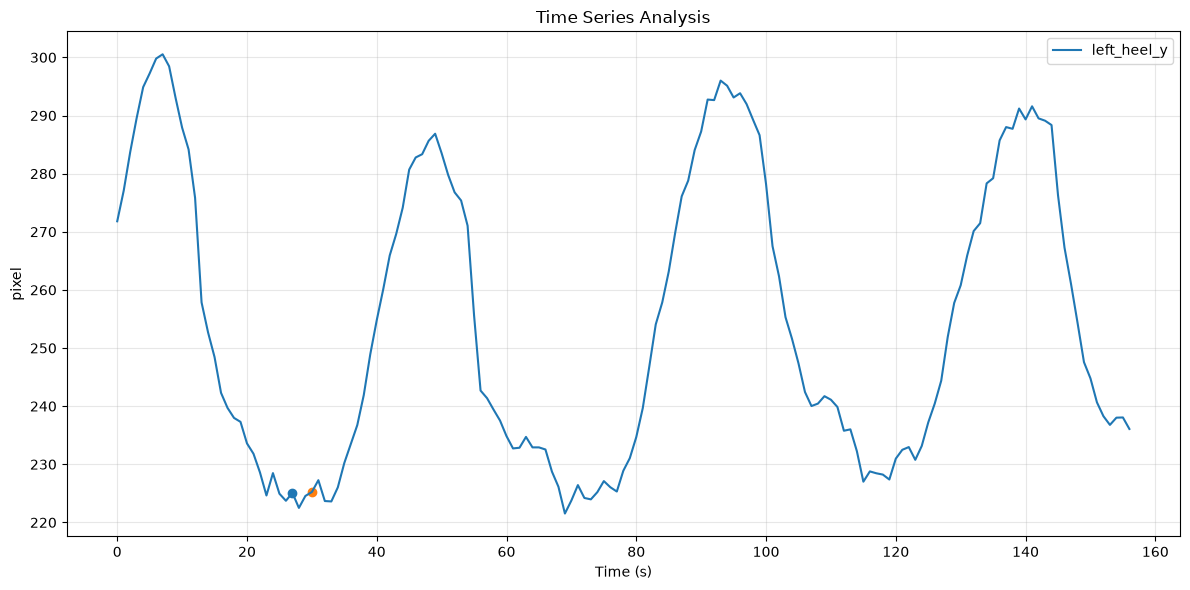

In [26]:
visualize_frame(ps.df[["left_heel_y"]], [27, 30])

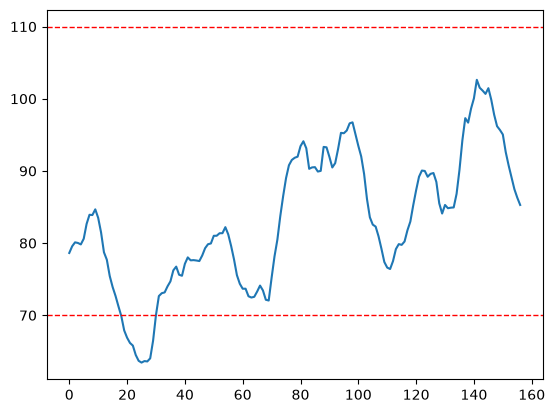

In [27]:
plt.plot(ps.joint_angle("left_elbow", smooth=True))
plt.axhline(y=70, color="red", linestyle="--", linewidth=1)
plt.axhline(y=110, color="red", linestyle="--", linewidth=1)

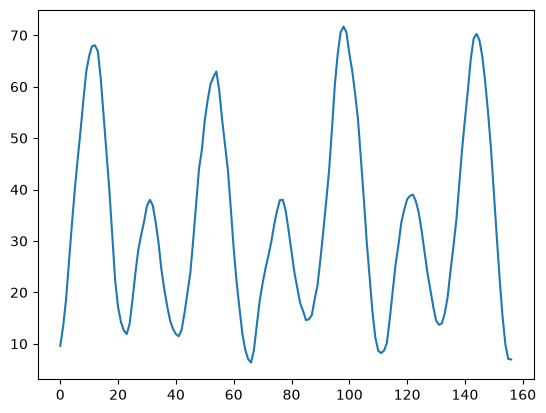

In [28]:
plt.plot(ps.joint_angle("left_knee", smooth=True, negative=True))

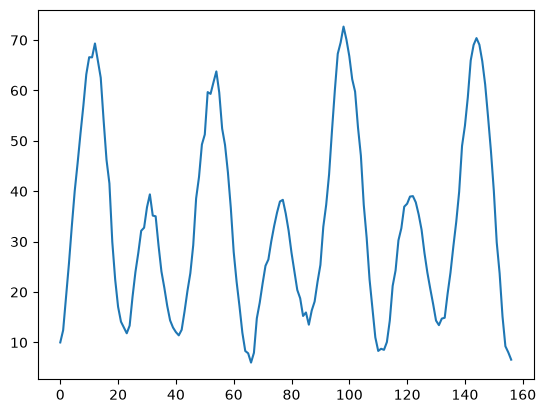

In [29]:
plt.plot(ps.joint_angle(("left_hip", "left_knee", "left_ankle"), negative=True))

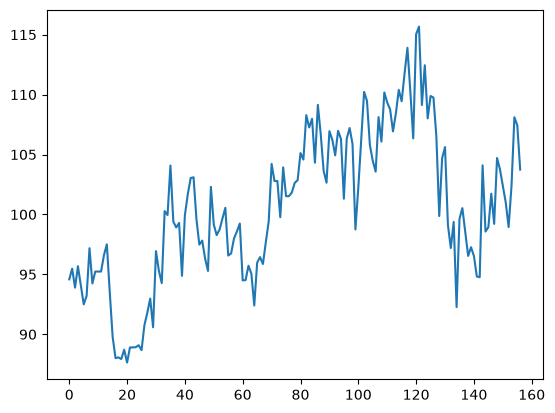

In [30]:
plt.plot(ps.joint_angle(("nose", "left_ear", "neck")))

In [31]:
ps.cal_stride()
ps.pixel2m()

이미 stride가 계산되어 있습니다.
Stride :    frame      value  class
1     12  68.043441      1
2     23  11.905859      0
3     31  38.002349      1
4     41  11.463123      0
1     54  62.956999      1
2     66   6.346456      0
3     77  37.995394      1
4     85  14.598677      0
1     98  71.685014      1
2    111   8.213956      0
3    122  39.025264      1
4    131  13.702387      0
1    144  70.255043      1
사용자의 키를 기반으로 계산한 픽셀당 meter는 0.0032082241987640447 / pixel 입니다.


np.float64(551.7070785395501)

In [32]:
ps.cal_stride()

이미 stride가 계산되어 있습니다.
Stride :    frame      value  class
1     12  68.043441      1
2     23  11.905859      0
3     31  38.002349      1
4     41  11.463123      0
1     54  62.956999      1
2     66   6.346456      0
3     77  37.995394      1
4     85  14.598677      0
1     98  71.685014      1
2    111   8.213956      0
3    122  39.025264      1
4    131  13.702387      0
1    144  70.255043      1


In [33]:
n = 0
while True:
    assert 0, "1"


AssertionError: 1

In [ ]:
n

10